# Notebook 3: ANN PyTorch Model
## Hyperspectral Data Science for Corn

**Objectives:**
- Load PCA-reduced datasets
- Build ANN architecture with PyTorch
- Train the model with validation
- Visualize training progress
- Evaluate model performance
- Save trained model

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load PCA-Reduced Data

In [2]:
# Load PCA datasets
X_train_pca = pd.read_csv('../data/X_train_pca.csv')
X_test_pca = pd.read_csv('../data/X_test_pca.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print("Data loaded successfully!")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded successfully!
X_train_pca shape: (400, 3)
X_test_pca shape: (100, 3)
y_train shape: (400,)
y_test shape: (100,)


## 2. Convert to PyTorch Tensors

In [3]:
# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_pca.values).to(device)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test_pca.values).to(device)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1).to(device)

print("Tensors created successfully!")
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

Tensors created successfully!
X_train_tensor shape: torch.Size([400, 3])
y_train_tensor shape: torch.Size([400, 1])


## 3. Create DataLoaders

In [4]:
# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 32
Number of training batches: 13
Number of test batches: 4


## 4. Define ANN Architecture

In [5]:
# ANN Model
class CornANN(nn.Module):
    def __init__(self, input_size):
        super(CornANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Initialize model
input_size = X_train_pca.shape[1]
model = CornANN(input_size).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Model Architecture:
CornANN(
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 10881


## 5. Define Loss and Optimizer

In [6]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function: MSE")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: MSE
Optimizer: Adam
Learning rate: 0.001


## 6. Training Loop

In [7]:
# Training function
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Validation function
def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

print("Training functions defined!")

Training functions defined!


In [8]:
# Train the model
epochs = 100
train_losses = []
val_losses = []

print("Starting training...\n")
for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_epoch(model, test_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\n✓ Training completed!")

Starting training...

Epoch [10/100] - Train Loss: 140822668.1538, Val Loss: 220021989.7578
Epoch [20/100] - Train Loss: 119926352.6923, Val Loss: 179929698.7500
Epoch [30/100] - Train Loss: 117225522.6154, Val Loss: 134393908.3750
Epoch [40/100] - Train Loss: 78073269.4615, Val Loss: 100422880.4844
Epoch [50/100] - Train Loss: 66856464.4712, Val Loss: 90823294.6719
Epoch [60/100] - Train Loss: 72918022.2308, Val Loss: 83584633.6641
Epoch [70/100] - Train Loss: 73021681.5962, Val Loss: 80157154.1875
Epoch [80/100] - Train Loss: 67257680.5769, Val Loss: 76180087.1992
Epoch [90/100] - Train Loss: 69030242.7692, Val Loss: 76089240.9453
Epoch [100/100] - Train Loss: 84829178.5192, Val Loss: 73437008.3320

✓ Training completed!


## 7. Visualize Training Progress

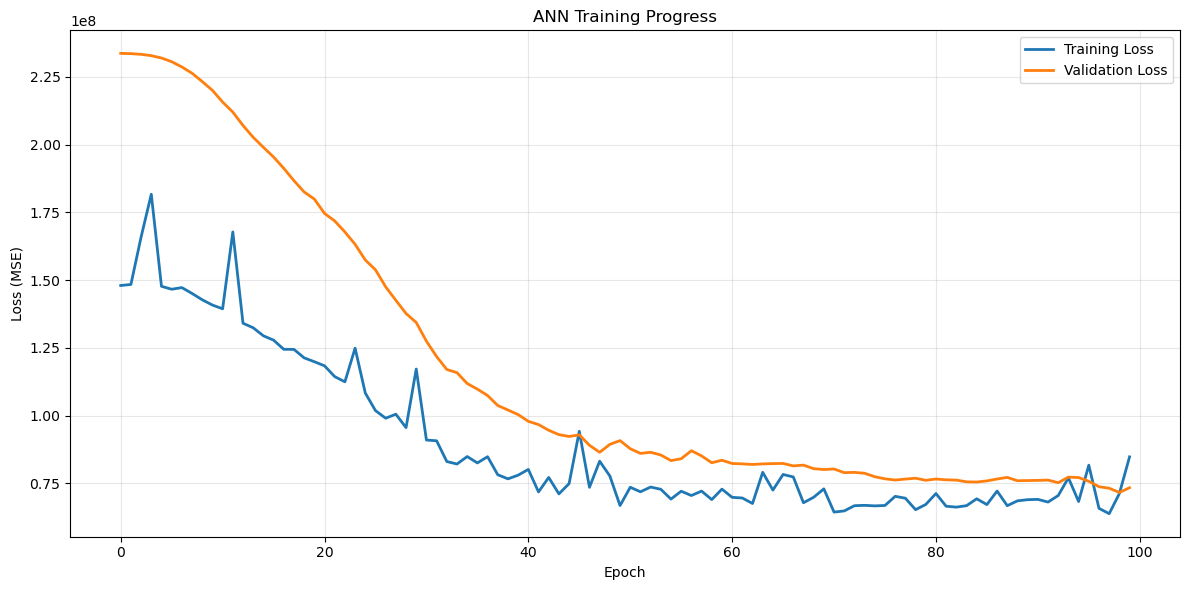

In [9]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('ANN Training Progress')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/ann_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Model Predictions

In [10]:
# Make predictions
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_tensor).cpu().numpy()
    y_test_pred = model(X_test_tensor).cpu().numpy()

print("Predictions generated!")
print(f"Train predictions shape: {y_train_pred.shape}")
print(f"Test predictions shape: {y_test_pred.shape}")

Predictions generated!
Train predictions shape: (400, 1)
Test predictions shape: (100, 1)


## 9. Model Evaluation

In [11]:
# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("="*60)
print("ANN MODEL PERFORMANCE")
print("="*60)
print("\nTraining Set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")
print("\nTest Set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")
print("="*60)

ANN MODEL PERFORMANCE

Training Set:
  RMSE: 8244.6074
  MAE:  2540.6807
  R²:   0.5271

Test Set:
  RMSE: 9693.8108
  MAE:  3244.2820
  R²:   0.6638


## 10. Prediction vs Actual Visualization

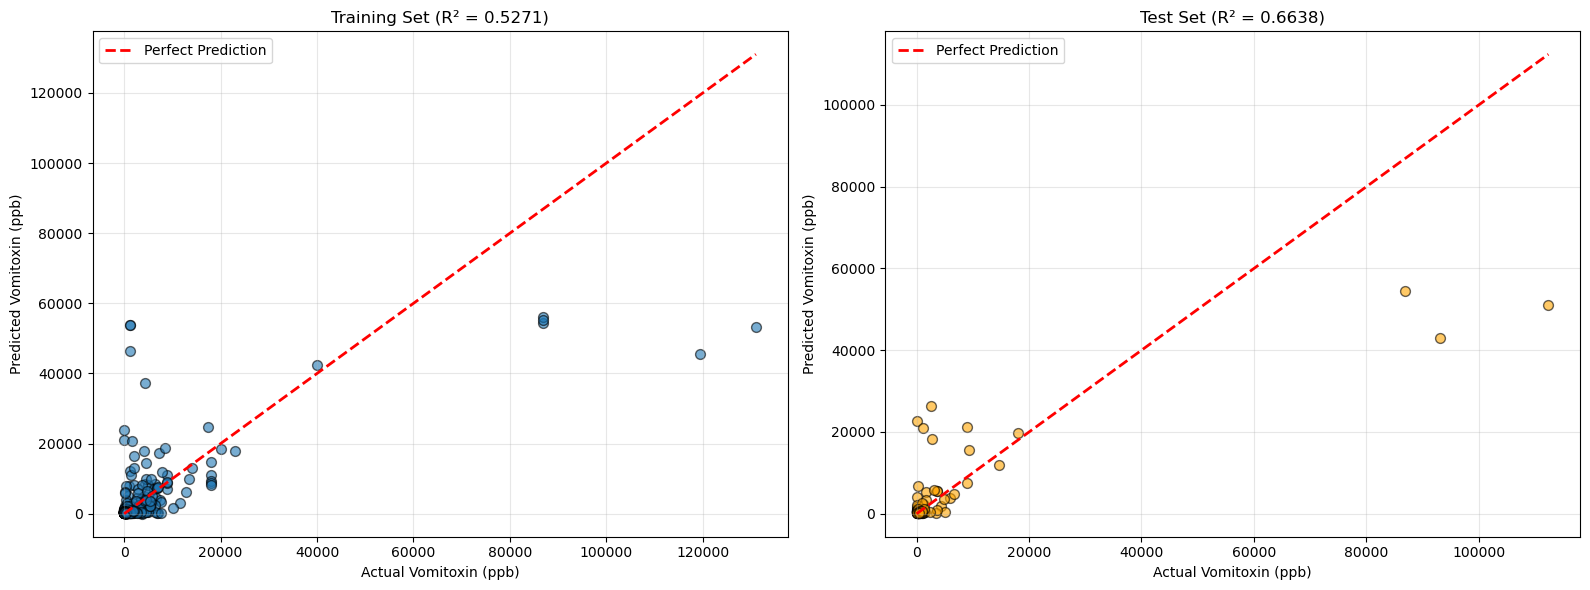

In [12]:
# Prediction vs Actual plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='black', s=50)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Vomitoxin (ppb)')
axes[0].set_ylabel('Predicted Vomitoxin (ppb)')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black', s=50, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Vomitoxin (ppb)')
axes[1].set_ylabel('Predicted Vomitoxin (ppb)')
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/ann_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Residual Analysis

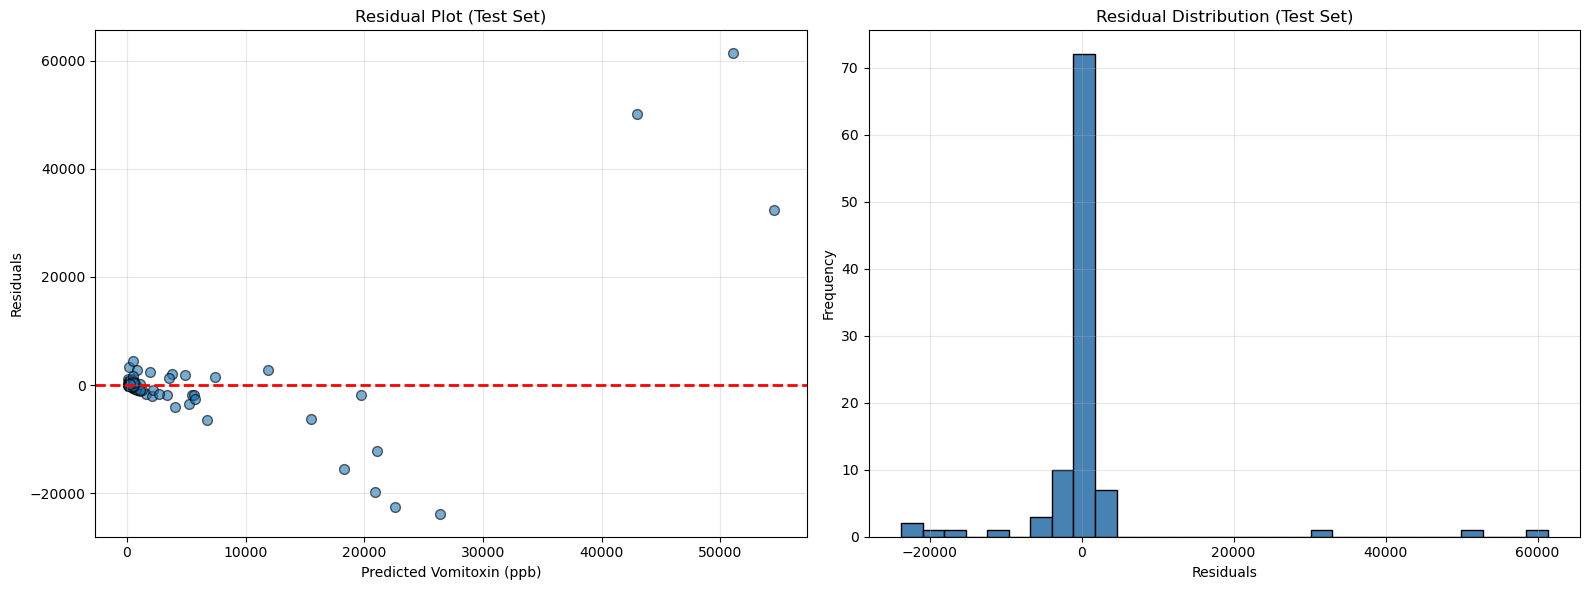

In [13]:
# Calculate residuals
train_residuals = y_train - y_train_pred.flatten()
test_residuals = y_test - y_test_pred.flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual plot
axes[0].scatter(y_test_pred, test_residuals, alpha=0.6, edgecolors='black', s=50)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Vomitoxin (ppb)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot (Test Set)')
axes[0].grid(alpha=0.3)

# Residual distribution
axes[1].hist(test_residuals, bins=30, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution (Test Set)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/ann_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Save Model

In [14]:
# Save the trained model
torch.save(model.state_dict(), '../models/trained_ann_model.pth')
print("✓ Model saved successfully!")
print("\nSaved file:")
print("  - trained_ann_model.pth")

✓ Model saved successfully!

Saved file:
  - trained_ann_model.pth


## 13. Save Results

In [15]:
# Save results to CSV
results_df = pd.DataFrame({
    'Model': ['ANN (PyTorch)'],
    'Train_RMSE': [train_rmse],
    'Train_MAE': [train_mae],
    'Train_R2': [train_r2],
    'Test_RMSE': [test_rmse],
    'Test_MAE': [test_mae],
    'Test_R2': [test_r2]
})

results_df.to_csv('../outputs/ann_results.csv', index=False)
print("✓ Results saved to ann_results.csv")

✓ Results saved to ann_results.csv


## 14. Summary

In [16]:
print("="*60)
print("NOTEBOOK 3: ANN PYTORCH MODEL - COMPLETED")
print("="*60)
print(f"\n✓ Model architecture: 4 layers (128-64-32-1)")
print(f"✓ Activation: ReLU")
print(f"✓ Dropout: 0.2")
print(f"✓ Optimizer: Adam (lr=0.001)")
print(f"✓ Epochs: {epochs}")
print(f"✓ Batch size: {batch_size}")
print(f"\n✓ Test R² Score: {test_r2:.4f}")
print(f"✓ Test RMSE: {test_rmse:.4f}")
print(f"✓ Test MAE: {test_mae:.4f}")
print("\n✓ Model saved successfully")
print("✓ Visualizations saved: 3 plots")
print("\n" + "="*60)
print("Ready for Notebook 4: Traditional ML Models")
print("="*60)

NOTEBOOK 3: ANN PYTORCH MODEL - COMPLETED

✓ Model architecture: 4 layers (128-64-32-1)
✓ Activation: ReLU
✓ Dropout: 0.2
✓ Optimizer: Adam (lr=0.001)
✓ Epochs: 100
✓ Batch size: 32

✓ Test R² Score: 0.6638
✓ Test RMSE: 9693.8108
✓ Test MAE: 3244.2820

✓ Model saved successfully
✓ Visualizations saved: 3 plots

Ready for Notebook 4: Traditional ML Models
